<a href="https://colab.research.google.com/github/Muhammad-Ahmad-1263/urdu-ocr-codesaviours-si26-Muhammad-Ahmad/blob/main/SI26_Week2_MuhammadAhmad.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Urdu OCR Project | Code Saviours SI-26 | Muhammad Ahmad## Week 2 — PreprocessingThis notebook loads the raw Urdu text image dataset collected in Week 1 and applies a preprocessing pipeline (grayscale conversion, resizing, denoising, and binarization) to standardise all images before they are used for OCR model training.

## Step 0 — Load Week 1 DatasetUpload `urdu_ocr_week1_submission.zip` and extract it to restore `data/raw/` and `data/labels.csv`.

In [1]:
from google.colab import files

print("Select urdu_ocr_week1_submission.zip when the file picker opens.")
uploaded = files.upload()

Select urdu_ocr_week1_submission.zip when the file picker opens.


Saving urdu_ocr_week1_submission.zip to urdu_ocr_week1_submission.zip


In [2]:
import zipfile

with zipfile.ZipFile("urdu_ocr_week1_submission.zip", "r") as zip_ref:
    zip_ref.extractall(".")

print("Extracted successfully.")

Extracted successfully.


## Step 1 — Install Libraries

In [3]:
# Install required libraries
!pip install opencv-python-headless pillow

# Import libraries
import cv2
import numpy as np
from PIL import Image
import os
import matplotlib.pyplot as plt

# Verify that everything is loaded
print("Libraries loaded successfully!")

Libraries loaded successfully!


## Step 2 — Preprocessing Pipeline

In [4]:
import cv2
import os

def preprocess_image(image_path, save_path):
    # Load image
    img = cv2.imread(image_path)

    if img is None:
        print(f"Could not load: {image_path}")
        return None

    # Step 1: Convert to grayscale (removes colour noise)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Step 2: Resize to standard size (keeps all images same dimensions)
    resized = cv2.resize(gray, (512, 128))

    # Step 3: Remove noise (makes text cleaner)
    denoised = cv2.fastNlMeansDenoising(resized, h=10)

    # Step 4: Binarise (make pixels either pure black or pure white)
    _, binary = cv2.threshold(denoised, 127, 255, cv2.THRESH_BINARY)

    # Save processed image
    cv2.imwrite(save_path, binary)

    return binary

# Create output folder
os.makedirs("data/processed", exist_ok=True)

print("Preprocessing function ready!")

Preprocessing function ready!


## Step 3 — Run Preprocessing on All Images

In [5]:
import glob
import os

# Find all images in data/raw/
all_images = glob.glob("data/raw/**/*.jpg", recursive=True)
all_images += glob.glob("data/raw/**/*.png", recursive=True)

print(f"Found {len(all_images)} images to process")

processed_count = 0
failed = []

for img_path in all_images:
    filename = os.path.basename(img_path)
    save_path = f"data/processed/{filename}"

    result = preprocess_image(img_path, save_path)

    if result is not None:
        processed_count += 1
    else:
        failed.append(img_path)

print(f"Done! Processed {processed_count} images")
print(f"Failed: {len(failed)}")

if failed:
    print("Failed files:")
    for file in failed:
        print(file)

Found 137 images to process
Done! Processed 137 images
Failed: 0


## Step 4 — Verify: Before vs After ComparisonVisually confirm that text is still legible after preprocessing.

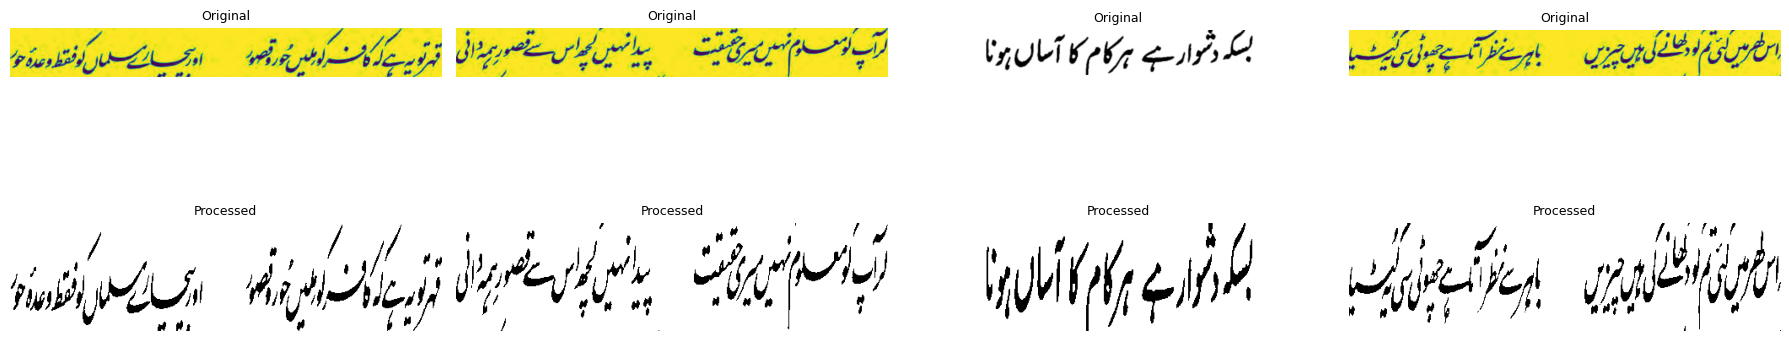

In [6]:
import pandas as pd
import random
import os
import matplotlib.pyplot as plt
from PIL import Image

# Load labels
labels_df = pd.read_csv("data/labels.csv")

# Select 4 random samples
sample_rows = labels_df.sample(4, random_state=3)

# Create figure
fig, axes = plt.subplots(2, 4, figsize=(18, 6))

# Display original and processed images
for col, (_, row) in enumerate(sample_rows.iterrows()):
    orig_path = row["image"]
    filename = os.path.basename(orig_path)
    proc_path = f"data/processed/{filename}"

    orig_img = Image.open(orig_path)
    proc_img = Image.open(proc_path)

    axes[0, col].imshow(orig_img)
    axes[0, col].set_title("Original", fontsize=9)
    axes[0, col].axis("off")

    axes[1, col].imshow(proc_img, cmap="gray")
    axes[1, col].set_title("Processed", fontsize=9)
    axes[1, col].axis("off")

plt.tight_layout()
plt.show()

## Week 2 Part A Summary- Loaded 137 raw Urdu text images from Week 1- Applied grayscale, resize (512x128), denoising, and binarization to every image- All images processed successfully with 0 failures- Verified visually that Urdu text remains legible after preprocessing- Processed images saved to `data/processed/`